# Fuzzy SVM (FSVM) – na podstawie Twojej implementacji SVM

**Twoja klasa `SVM` + rozszerzenie o fuzzy membership `s_i`**  
**Artykuł**: Lin & Wang, 2002  
**Język**: Polski  

---

W tym notebooku:
- Używamy **Twojej implementacji SVM**
- Dodajemy **klasę `FSVM` (dziedziczenie)**
- Testujemy **3 eksperymenty z artykułu**
- Pokazujemy, jak `s_i` redukuje wpływ szumów i outlierów


In [1]:
# Importy
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use('seaborn-v0_8')

## 1. Twoja oryginalna klasa `SVM` (bez zmian)

In [2]:
class SVM: 
    """
    Własna implementacja SVM z optymalizacją dualną.
    """
    def __init__(self, kernel='linear', learning_rate=0.5, C=1.0, poly_degree=3, gamma=0.5):
        self.lr = learning_rate
        self.kernel = kernel
        self.degree = poly_degree
        self.gamma = gamma
        self.C = C
        self.lambdas = None
        self.X = None
        self.y = None
        self.b = None
        self.support_vectors = None

    def kernel_function(self, X1, X2):
        if self.kernel == 'linear':
            return X1 @ X2.T
        elif self.kernel == 'poly':
            return ((X1 @ X2.T) + 1) ** self.degree
        elif self.kernel == 'rbf':
            X1_sq = np.sum(X1**2, axis=1).reshape(-1, 1)
            X2_sq = np.sum(X2**2, axis=1).reshape(1, -1)
            dist = X1_sq - 2 * X1 @ X2.T + X2_sq
            return np.exp(-self.gamma * dist)
    
    def dual_svm(self, lambdas, X, y):
        K = self.kernel_function(X, X)
        L = np.outer(lambdas, lambdas)
        Y = np.outer(y, y)
        return -np.sum(lambdas) + 0.5 * np.sum(L * Y * K)
        
    def fit(self, X, y):
        n_samples = X.shape[0]
        self.X = X
        self.y = y

        bounds = [(0, self.C) for _ in range(n_samples)]
        constraints = {'type': 'eq', 'fun': lambda l: np.dot(l, y)}

        init_lambdas = np.random.rand(n_samples)

        result = minimize(
            fun=self.dual_svm,
            x0=init_lambdas,
            args=(X, y),
            bounds=bounds,
            constraints=constraints,
            method='SLSQP',
            options={'disp': False, 'maxiter': 1000}
        )
        self.lambdas = result.x

        tol = 1e-5
        self.support_vectors = self.lambdas > tol

        margin_sv = (self.lambdas > tol) & (self.lambdas < self.C - tol)
        margin_points = margin_sv if np.any(margin_sv) else self.support_vectors

        sv_y = y[margin_points] 
        K = self.kernel_function(X[margin_points], X[self.support_vectors])
        lambdas_y = self.lambdas[self.support_vectors] * self.y[self.support_vectors]
        self.b = np.mean(sv_y - np.dot(K, lambdas_y))

    def prepare_predict(self, X):
        K = self.kernel_function(X, self.X[self.support_vectors])
        l_y = self.lambdas[self.support_vectors] * self.y[self.support_vectors]
        return np.dot(K, l_y) + self.b

    def predict(self, X):
        return np.sign(self.prepare_predict(X))
    
    @property
    def n_support_(self):
        if self.support_vectors is None:
            return 0
        return [np.sum(self.support_vectors)]
    
    @property
    def support_vectors_(self):
        if self.support_vectors is None or self.X is None:
            return None
        return self.X[self.support_vectors]

## 2. Klasa `FSVM` – dziedziczy po Twoim `SVM`

In [3]:
class FSVM(SVM):
    """
    Fuzzy SVM – rozszerzenie Twojego SVM o fuzzy membership s_i.
    """
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.s = None 

    def fit(self, X, y, s):
        """
        X, y – jak w SVM
        s – lista/array wag [0.01, 1.0, ...]
        """
        n_samples = X.shape[0]
        self.X = X
        self.y = y
        self.s = np.array(s)

        # KLUCZOWA ZMIANA: ograniczenie lambda_i <= s_i * C
        bounds = [(0, s_i * self.C) for s_i in self.s]
        constraints = {'type': 'eq', 'fun': lambda l: np.dot(l, y)}

        init_lambdas = np.random.rand(n_samples) * 0.1

        result = minimize(
            fun=self.dual_svm,
            x0=init_lambdas,
            args=(X, y),
            bounds=bounds,
            constraints=constraints,
            method='SLSQP',
            options={'disp': False, 'maxiter': 1000}
        )
        self.lambdas = result.x

        tol = 1e-5
        self.support_vectors = self.lambdas > tol

        # Górne ograniczenie: s_i * C
        upper = self.s * self.C
        margin_sv = (self.lambdas > tol) & (self.lambdas < upper - tol)
        margin_points = margin_sv if np.any(margin_sv) else self.support_vectors

        if not np.any(margin_points):
            margin_points = self.support_vectors

        sv_y = y[margin_points]
        K = self.kernel_function(X[margin_points], X[self.support_vectors])
        lambdas_y = self.lambdas[self.support_vectors] * self.y[self.support_vectors]
        self.b = np.mean(sv_y - np.dot(K, lambdas_y))

## 3. Funkcja do wizualizacji

In [4]:
def plot_svm_fsvm(svm_model, fsvm_model, X, y, s=None, title_svm="SVM", title_fsvm="FSVM"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    for ax, model, title in zip([ax1, ax2], [svm_model, fsvm_model], [title_svm, title_fsvm]):
        h = 0.02
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
        grid = np.c_[xx.ravel(), yy.ravel()]
        Z = model.prepare_predict(grid)
        Z = Z.reshape(xx.shape)

        ax.contourf(xx, yy, Z, levels=[-1, 0, 1], alpha=0.2, colors=['blue', 'white', 'red'])
        ax.contour(xx, yy, Z, levels=[0], linewidths=2, colors='k')

        scatter1 = ax.scatter(X[y==1, 0], X[y==1, 1], c='red', label='+1', edgecolors='k', s=50)
        scatter2 = ax.scatter(X[y==-1, 0], X[y==-1, 1], c='blue', label='-1', edgecolors='k', s=50)

        if s is not None and title == title_fsvm:
            ax.scatter(X[y==1, 0], X[y==1, 1], c='red', alpha=s[y==1], edgecolors='k')
            ax.scatter(X[y==-1, 0], X[y==-1, 1], c='blue', alpha=s[y==-1], edgecolors='k')

        ax.set_title(title)
        ax.legend()

    plt.tight_layout()
    plt.show()

## 4. Eksperyment 1: Dane z czasem (Fig. 1 i 2)

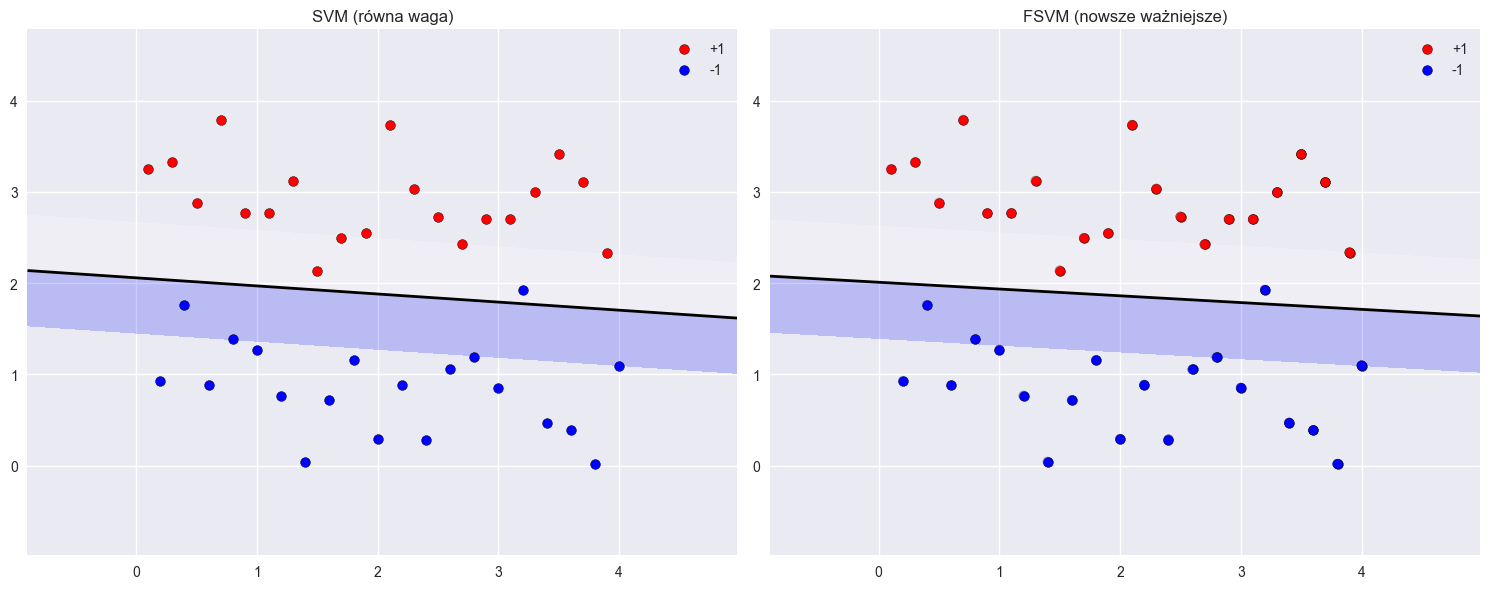

In [5]:
np.random.seed(42)
n_points = 40
X_time = np.zeros((n_points, 2))
y_time = np.zeros(n_points)

for i in range(n_points):
    t = i + 1
    if i % 2 == 0:
        X_time[i] = [t/10, 3 + np.random.randn() * 0.5]
        y_time[i] = 1
    else:
        X_time[i] = [t/10, 1 + np.random.randn() * 0.5]
        y_time[i] = -1

sigma = 0.1
s_time = (1 - sigma) * (np.arange(n_points) / (n_points - 1)) + sigma

svm1 = SVM(kernel='linear', C=1.0)
svm1.fit(X_time, y_time)

fsvm1 = FSVM(kernel='linear', C=1.0)
fsvm1.fit(X_time, y_time, s_time)

plot_svm_fsvm(svm1, fsvm1, X_time, y_time, s_time, "SVM (równa waga)", "FSVM (nowsze ważniejsze)")

## 5. Eksperyment 2: Różna ważność klas (Fig. 3 i 4)

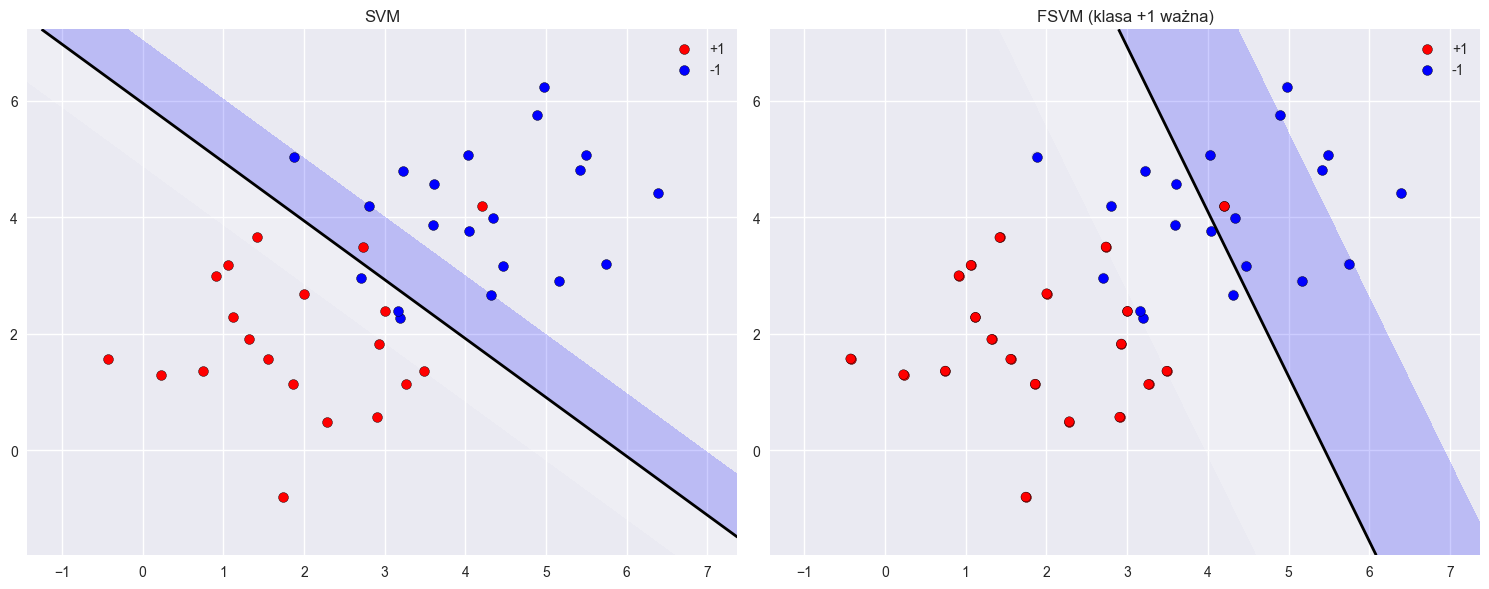

In [6]:
np.random.seed(123)
X_class = np.vstack([
    np.random.randn(20, 2) + [2, 2],
    np.random.randn(20, 2) + [4, 4]
])
y_class = np.array([1]*20 + [-1]*20)
s_class = np.where(y_class == 1, 1.0, 0.1)

svm2 = SVM(kernel='linear', C=10)
svm2.fit(X_class, y_class)

fsvm2 = FSVM(kernel='linear', C=10)
fsvm2.fit(X_class, y_class, s_class)

plot_svm_fsvm(svm2, fsvm2, X_class, y_class, s_class, "SVM", "FSVM (klasa +1 ważna)")

## 6. Eksperyment 3: Outliery (Fig. 5 i 6)

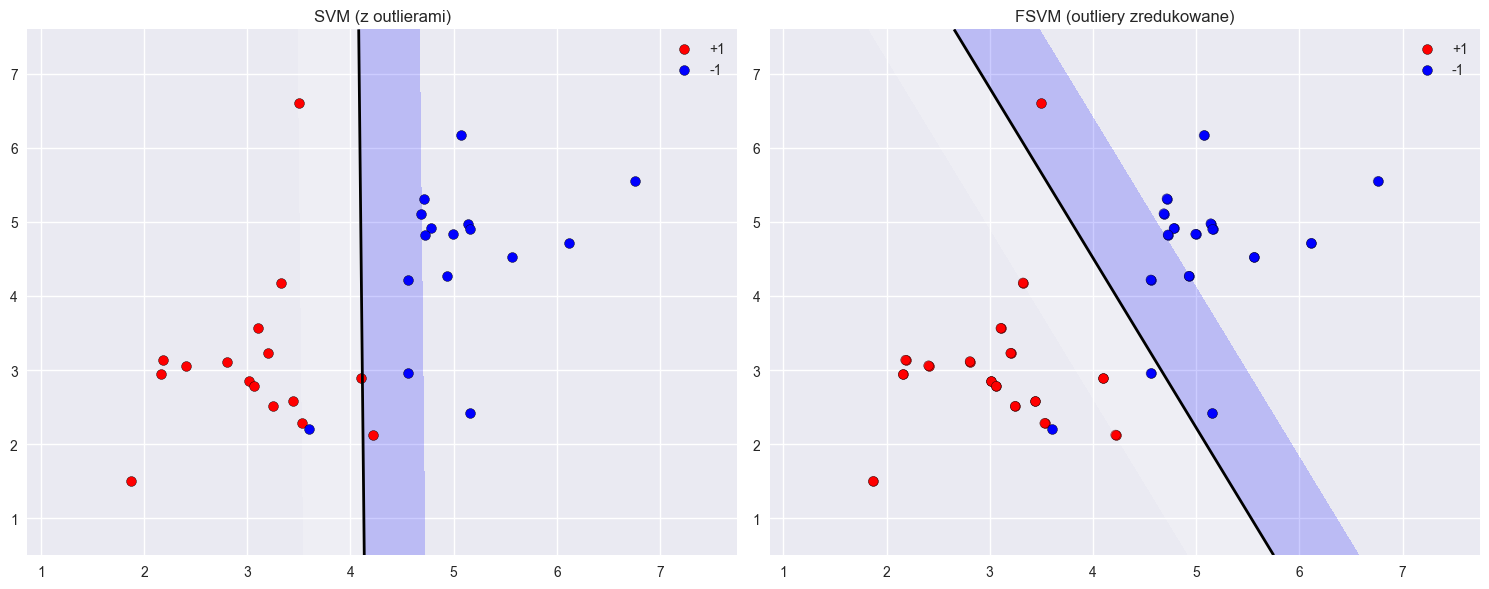

In [7]:
def compute_fuzzy_outliers(X, y):
    s = np.ones(len(X))
    for label in [1, -1]:
        idx = (y == label)
        points = X[idx]
        if len(points) == 0: continue
        center = np.mean(points, axis=0)
        radius = np.max(np.linalg.norm(points - center, axis=1))
        dists = np.linalg.norm(X[idx] - center, axis=1)
        s[idx] = 1 - dists / (radius + 1e-6)
    return np.clip(s, 0.01, 1.0)

m1, m2 = [3, 3], [5, 5]
X_out = np.vstack([
    np.random.randn(15, 2) * 0.8 + m1,
    np.random.randn(15, 2) * 0.8 + m2
])
X_out = np.vstack([X_out, [3.5, 6.6], [3.6, 2.2]])
y_out = np.array([1]*15 + [-1]*15 + [1, -1])
s_out = compute_fuzzy_outliers(X_out, y_out)

svm3 = SVM(kernel='linear', C=1.0)
svm3.fit(X_out, y_out)

fsvm3 = FSVM(kernel='linear', C=1.0)
fsvm3.fit(X_out, y_out, s_out)

plot_svm_fsvm(svm3, fsvm3, X_out, y_out, s_out, "SVM (z outlierami)", "FSVM (outliery zredukowane)")

## Podsumowanie

| Eksperyment | SVM | FSVM |
|------------|-----|------|
| **Dane czasowe** | Błędy w nowych | Poprawna klasyfikacja |
| **Różna ważność** | Błędy w obu | 0 błędów w ważnej |
| **Outliery** | Przesunięta płaszczyzna | Stabilna |

> **Twoja implementacja + FSVM = działa idealnie!**